# Experiment B2: FedProx + Strong FocalTversky Loss (No SCWA)
## Phase 4 — Federated Small-Lesion Dice Fairness (FeTS 2022)
---
**Experiment B2 — Critical control:**
Strong FocalTversky (LAMBDA=2.0, beta=0.85) + FedProx (μ=0.01) + standard FedAvg aggregation.
**No SCWA.** This is the ablation control that isolates FedProx's effect without the aggregation fix.
Purpose: show that FedProx alone (without SCWA-LW) does not improve — and actually hurts —
small-tumour performance. Comparing C vs B2 gives the cleanest measure of SCWA-LW's contribution.

**All 7 Phase-3 failures fixed:**
1. Stratified val split — small lesions in every client val set
2. Two-stage pipeline — deterministic preprocessing cached; random augmentation fresh each access
3. Larger model channels (32,64,128,256,320) ~18M params
4. 30 rounds
5. Enhanced augmentation: flips + noise + intensity scale/shift
6. Strong FocalTversky: beta=0.85, gamma=2.0, lambda=2.0
7. SWI overlap=0.75; harmonic-mean model selection


## 1. Install and mount

In [ ]:
!pip -q install monai nibabel
from google.colab import drive
drive.mount('/content/drive')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 66.1 MB/s eta 0:00:00
Mounted at /content/drive


## 1b. Clean up old Drive cache (run once)

Old notebook versions saved the preprocessing cache to Drive (5-35 GB each). Run this once to delete those folders and reclaim space. Safe to skip if not needed.

In [ ]:
# import shutil
# from pathlib import Path

# # Deletes old cache folders accidentally saved to Drive by previous notebook versions.
# # Current notebook caches to local /content/ only — zero Drive usage.
# drive_root = Path('/content/drive/MyDrive')
# freed = 0
# for folder in drive_root.glob('fets_scwa_cache_*'):
#     if folder.is_dir():
#         sz = sum(f.stat().st_size for f in folder.rglob('*') if f.is_file())
#         shutil.rmtree(str(folder))
#         freed += sz
#         print(f"Deleted: {folder.name}  ({sz/1e9:.2f} GB)")

# if freed == 0:
#     print("No old Drive cache folders found.")
# else:
#     print(f"Total freed: {freed/1e9:.2f} GB")
# print("Cache is now local-only — zero Drive quota used.")


## 2. Imports

In [ ]:
import os, re, gc, json, math, copy, random, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

import torch
import torch.nn as nn

from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, NormalizeIntensityd,
    ConcatItemsd, DeleteItemsd, CropForegroundd, SpatialPadd,
    RandCropByPosNegLabeld, RandFlipd, RandGaussianNoised,
    RandScaleIntensityd, RandShiftIntensityd, ToTensord,
)
from monai.data import Dataset, PersistentDataset, DataLoader

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    try: torch.set_float32_matmul_precision('high')
    except Exception: pass


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Device: cuda


## 3. Configuration

In [ ]:
# ===== paths =====
TRAIN_ROOT       = Path('/content/drive/MyDrive/FeTS_unzipped/train/MICCAI_FeTS2022_TrainingData')
PARTITIONS_JSON  = Path('/content/drive/MyDrive/final_data_partitions.json')
STATS_CSV_CANDIDATES = [
    Path('/content/master_lesion_stats.csv'),
    Path('/content/drive/MyDrive/master_lesion_stats.csv'),
]
OUTPUT_DIR = Path('/content/drive/MyDrive/fets_scwa_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- CACHE on local SSD (fast, free, rebuilt each session ~10 min) ----
CACHE_VERSION = 'v1_b2'
CACHE_DIR = Path(f'/content/fets_b2_cache_{CACHE_VERSION}')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ===== experiments =====
EXPERIMENTS_TO_RUN = ['fedprox_lft_strong']

METHOD_PRESETS = {
    # B2: FedProx (mu=0.01) + Strong FTL — NO SCWA.
    # Server aggregation is standard FedAvg (sample-count weights).
    # Purpose: isolate FedProx's effect without the aggregation fix.
    'fedprox_lft_strong': {
        'use_prox': True,
        'use_lft': True,
        'prox_mu': 0.01,
    },
}

# ===== partitioning =====
N_CLIENTS         = 5
DIRICHLET_ALPHA   = 0.5
CLIENT_MAX_CASES  = 80
VAL_PER_CLIENT    = 10
SMALL_THRESH_CM3  = 30.0
MEDIUM_THRESH_CM3 = 100.0

# ===== hardware =====
GPU_TOTAL_GB = 0.0
if torch.cuda.is_available():
    GPU_TOTAL_GB = torch.cuda.get_device_properties(0).total_memory / 1024**3
HIGH_VRAM          = GPU_TOTAL_GB >= 30.0
TRAIN_BATCH_SIZE   = 4 if HIGH_VRAM else 2
TRAIN_PATCHES_PER  = 4
TRAIN_POS          = 3
TRAIN_NEG          = 1
NUM_WORKERS        = 2

# ===== model =====
MODEL_CHANNELS  = (32, 64, 128, 256, 320)
MODEL_STRIDES   = (2, 2, 2, 2)
MODEL_RES_UNITS = 2

# ===== training =====
ROUNDS        = 30
LOCAL_EPOCHS  = 3
LR            = 1e-4
WD            = 1e-5
ROI_SIZE      = (96, 96, 96)
USE_AMP       = torch.cuda.is_available()
USE_CL        = torch.cuda.is_available()

# ===== evaluation =====
SW_BATCH_SIZE    = 8 if HIGH_VRAM else 4
SW_OVERLAP       = 0.75
VAL_SW_OVERLAP   = 0.50
THRESHOLD        = 0.5
FULL_VAL_EVERY_N = 10

# ===== loss (fixed, non-adaptive) =====
LFT_ALPHA   = 0.3
LFT_BETA    = 0.85
LFT_GAMMA   = 2.0
LAMBDA_LFT  = 2.0

print(f'Device: {device} | GPU: {GPU_TOTAL_GB:.1f} GB | HIGH_VRAM: {HIGH_VRAM}')
print(f'Model channels: {MODEL_CHANNELS}')
print(f'Rounds: {ROUNDS} | Local epochs: {LOCAL_EPOCHS} | NUM_WORKERS: {NUM_WORKERS}')
print(f'Experiments: {EXPERIMENTS_TO_RUN}')


## 4. Stats, file resolution, test set

In [ ]:
def assign_group(v):
    v = float(v)
    if v < SMALL_THRESH_CM3: return 'small'
    if v <= MEDIUM_THRESH_CM3: return 'medium'
    return 'large'

def load_stats_df():
    for p in STATS_CSV_CANDIDATES:
        if Path(p).exists():
            print('Stats CSV:', p); df = pd.read_csv(p); break
    else:
        raise FileNotFoundError('master_lesion_stats.csv not found in candidates')
    if 'case_id' not in df.columns:
        for col in ['case_name','path','case','subject_id']:
            if col in df.columns:
                df['case_id'] = df[col].astype(str).apply(lambda x: Path(x).name); break
        else: raise ValueError('Cannot infer case_id')
    for vol_col in ['lesion_cm3','lesion_volume_cm3']:
        if vol_col in df.columns: df['lesion_cm3'] = df[vol_col].astype(float); break
    else:
        if 'lesion_volume' in df.columns: df['lesion_cm3'] = df['lesion_volume'].astype(float)/1000
        else: raise ValueError('Cannot find lesion volume column')
    df['size_group'] = df['lesion_cm3'].apply(assign_group)
    df['case_id'] = df['case_id'].astype(str)
    return df

stats_df    = load_stats_df()
stats_index = {r['case_id']: r for _, r in stats_df.iterrows()}

MOD_KEYS = ['flair','t1','t1ce','t2']

def modality_from_name(name):
    n = name.lower()
    if 'seg' in n: return 'seg'
    if 'flair' in n: return 'flair'
    if 't1ce' in n or 't1gd' in n: return 't1ce'
    if re.search(r'(^|[_\-.])t1([_\-.]|$)', n) and 't1ce' not in n: return 't1'
    if re.search(r'(^|[_\-.])t2([_\-.]|$)', n): return 't2'
    return None

def resolve_case_files(case_dir):
    case_dir = Path(case_dir)
    found, seg = {}, None
    for f in sorted(case_dir.glob('*.nii.gz')):
        k = modality_from_name(f.name)
        if k == 'seg': seg = str(f)
        elif k: found[k] = str(f)
    missing = [k for k in MOD_KEYS if k not in found]
    if seg is None or missing:
        raise RuntimeError(f'{case_dir.name}: missing modalities={missing} seg={seg is not None}')
    return {'case_name': case_dir.name, 'case_path': str(case_dir),
            'flair': found['flair'], 't1': found['t1'],
            't1ce': found['t1ce'], 't2': found['t2'], 'label': seg}

def attach_meta(case_dir):
    case_dir = Path(case_dir); name = case_dir.name
    row = stats_index.get(name)
    if row is not None:
        return {'case_path': case_dir, 'case_name': name,
                'lesion_cm3': float(row['lesion_cm3']),
                'size_group': str(row['size_group'])}
    segs = list(case_dir.glob('*seg*.nii.gz'))
    if len(segs) != 1: raise RuntimeError(f'{name}: expected 1 seg, found {len(segs)}')
    v = float((nib.load(str(segs[0])).get_fdata() > 0).sum()) / 1000.0
    return {'case_path': case_dir, 'case_name': name,
            'lesion_cm3': v, 'size_group': assign_group(v)}

# ---- locked-box test set ----
if not PARTITIONS_JSON.exists():
    raise FileNotFoundError(f'Not found: {PARTITIONS_JSON}')
with open(PARTITIONS_JSON) as fh: meta_lb = json.load(fh)
if 'test_set_paths' not in meta_lb: raise KeyError('PARTITIONS_JSON needs test_set_paths')
test_meta = [attach_meta(p) for p in meta_lb['test_set_paths']]
print(f'Test set: {len(test_meta)} cases')
print(pd.DataFrame(test_meta)['size_group'].value_counts().to_string())


Stats CSV: /content/drive/MyDrive/master_lesion_stats.csv
Test set: 90 cases
size_group
small     30
medium    30
large     30


## 5. Dirichlet partition + stratified cap + stratified val split

- **Dirichlet alpha=0.5** creates non-IID skew across clients
- **stratified_cap(max=80)** matches Phase-3 pool size (preserves small-case scarcity)
- **Stratified val split** guarantees small cases in every client val set (fixes Phase-3 root cause)


In [ ]:
if not TRAIN_ROOT.exists():
    raise FileNotFoundError(f'TRAIN_ROOT not found: {TRAIN_ROOT}')

train_dirs = sorted([p for p in TRAIN_ROOT.iterdir() if p.is_dir()])
dir_by_id = {p.name: p for p in train_dirs}

train_df = stats_df[stats_df['case_id'].isin(dir_by_id)].copy()
train_df['path'] = train_df['case_id'].map(dir_by_id)
train_df = train_df.dropna(subset=['path']).copy()

print(f'Initial training pool: {len(train_df)} cases')
print(train_df['size_group'].value_counts().to_string())

# IMPORTANT: remove locked test cases BEFORE client partitioning
test_case_ids = set([m["case_name"] for m in test_meta])

before = len(train_df)

train_df = train_df[
    ~train_df["case_id"].astype(str).isin(test_case_ids)
].copy()

after = len(train_df)

print(f"Removed {before - after} locked test cases from training pool.")
print(f"Final training pool after test removal: {after} cases")
print(train_df["size_group"].value_counts().to_string())

def dirichlet_partition(df, num_clients=5, alpha=0.5, seed=SEED):
    rng     = np.random.default_rng(seed)
    clients = {i: [] for i in range(num_clients)}
    for grp in ['small','medium','large']:
        gdf = df[df['size_group']==grp].sample(frac=1, random_state=seed)
        if len(gdf) == 0: continue
        props  = rng.dirichlet([alpha]*num_clients)
        splits = (props * len(gdf)).astype(int)
        splits[: len(gdf)-splits.sum()] += 1   # fix remainder
        start = 0
        for i in range(num_clients):
            end = start + splits[i]
            clients[i].extend([attach_meta(r['path'])
                                for _, r in gdf.iloc[start:end].iterrows()])
            start = end
    return [clients[i] for i in range(num_clients)]

def stratified_cap(meta_list, max_cases=CLIENT_MAX_CASES, seed=SEED):
    if len(meta_list) <= max_cases: return meta_list
    rng = random.Random(seed)
    by_grp = defaultdict(list)
    for m in meta_list: by_grp[m['size_group']].append(m)
    out = []
    for grp, cases in by_grp.items():
        n = max(1, round(len(cases)/len(meta_list)*max_cases))
        rng.shuffle(cases); out.extend(cases[:n])
    rng.shuffle(out)
    return out[:max_cases]

def stratified_val_split(client_meta_list, val_per_client=VAL_PER_CLIENT, seed=SEED):
    rng = random.Random(seed)
    train_by, val_by = [], []
    for meta_list in client_meta_list:
        meta_list = list(meta_list)
        total = len(meta_list)
        n_val = min(val_per_client, max(1, total//5))
        by_grp = defaultdict(list)
        for m in meta_list: by_grp[m['size_group']].append(m)
        val, train = [], []
        for grp, cases in by_grp.items():
            rng.shuffle(cases)
            n = max(0, round(len(cases)/total*n_val))
            n = min(n, len(cases))
            if len(cases) > 1 and n == 0 and len(val) < n_val: n = 1
            val.extend(cases[:n]); train.extend(cases[n:])
        if len(val) < n_val and train:
            rng.shuffle(train)
            d = n_val - len(val); val.extend(train[:d]); train = train[d:]
        train_by.append(train); val_by.append(val)
    return train_by, val_by

all_client_meta = dirichlet_partition(train_df)
all_client_meta = [stratified_cap(m, seed=SEED+i)
                   for i, m in enumerate(all_client_meta)]
train_meta_by_client, val_meta_by_client = stratified_val_split(all_client_meta)

n_cases_by_client = [len(tr) for tr in train_meta_by_client]
n_small_by_client = [sum(1 for m in tr if m['size_group']=='small')
                     for tr in train_meta_by_client]

print('Client distribution:')
print(f'{"C":<3}{"Tr":>5}{"Val":>5}{"S_tr":>6}{"M_tr":>6}{"L_tr":>6}'
      f'{"S_val":>7}{"M_val":>7}{"L_val":>7}')
for i in range(N_CLIENTS):
    tr = train_meta_by_client[i]; va = val_meta_by_client[i]
    c = lambda lst,g: sum(1 for m in lst if m['size_group']==g)
    print(f'{i:<3}{len(tr):>5}{len(va):>5}'
          f'{c(tr,"small"):>6}{c(tr,"medium"):>6}{c(tr,"large"):>6}'
          f'{c(va,"small"):>7}{c(va,"medium"):>7}{c(va,"large"):>7}')


Initial training pool: 1251 cases
size_group
medium    560
large     537
small     154
Removed 90 locked test cases from training pool.
Final training pool after test removal: 1161 cases
size_group
medium    530
large     507
small     124
Client distribution:
C     Tr  Val  S_tr  M_tr  L_tr  S_val  M_val  L_val
0     70   10     6     4    60      1      1      8
1     70   10    18    28    24      2      4      4
2     54   10     1    51     2      0     10      0
3     69   10     7    47    15      1      7      2
4     70   10     0    66     4      0      9      1


In [ ]:
test_case_ids = set([m["case_name"] for m in test_meta])

actual_train_ids = set()
actual_val_ids = set()

for client in train_meta_by_client:
    actual_train_ids.update([m["case_name"] for m in client])

for client in val_meta_by_client:
    actual_val_ids.update([m["case_name"] for m in client])

print("Actual train/test overlap:", len(actual_train_ids & test_case_ids))
print("Actual val/test overlap:", len(actual_val_ids & test_case_ids))
print("Actual train/val overlap:", len(actual_train_ids & actual_val_ids))

assert len(actual_train_ids & test_case_ids) == 0, "Train/test leakage found"
assert len(actual_val_ids & test_case_ids) == 0, "Val/test leakage found"
assert len(actual_train_ids & actual_val_ids) == 0, "Train/val leakage found"

print("✅ No leakage in actual train/val/test splits.")

Actual train/test overlap: 0
Actual val/test overlap: 0
Actual train/val overlap: 0
✅ No leakage in actual train/val/test splits.


## 6. Transforms and datasets

**Two-stage pipeline:**
- Stage 1 `preprocess_transforms` — deterministic. Cached in RAM by `CacheDataset`.
- Stage 2 `augment_transforms` — random. Applied fresh on every `__getitem__`.

Uses in-memory cache (`CacheDataset`) rather than disk (`PersistentDataset`) to avoid
filling the 112 GB local Colab disk. RAM cache (~15-25 GB) is faster and disk-free.

In [ ]:
from monai.data import CacheDataset, pad_list_data_collate

# ---- Stage 1: deterministic preprocessing (cached in RAM) ----
preprocess_transforms = Compose([
    LoadImaged(keys=MOD_KEYS + ['label']),
    EnsureChannelFirstd(keys=MOD_KEYS + ['label']),
    NormalizeIntensityd(keys=MOD_KEYS, nonzero=True, channel_wise=True),
    ConcatItemsd(keys=MOD_KEYS, name='image', dim=0),
    DeleteItemsd(keys=MOD_KEYS),
    CropForegroundd(keys=['image','label'], source_key='image'),
    SpatialPadd(keys=['image','label'], spatial_size=ROI_SIZE),
    ToTensord(keys=['image','label']),
])

# ---- Stage 2: random augmentation (never cached, always fresh) ----
augment_transforms = Compose([
    RandCropByPosNegLabeld(
        keys=['image','label'], label_key='label',
        spatial_size=ROI_SIZE, pos=TRAIN_POS, neg=TRAIN_NEG,
        num_samples=TRAIN_PATCHES_PER, image_key='image', image_threshold=0.0,
    ),
    RandFlipd(keys=['image','label'], prob=0.5, spatial_axis=0),
    RandFlipd(keys=['image','label'], prob=0.5, spatial_axis=1),
    RandFlipd(keys=['image','label'], prob=0.5, spatial_axis=2),
    RandGaussianNoised(keys=['image'], prob=0.15, mean=0.0, std=0.05),
    RandScaleIntensityd(keys=['image'], factors=0.1, prob=0.3),
    RandShiftIntensityd(keys=['image'], offsets=0.1, prob=0.3),
    ToTensord(keys=['image','label']),
])

# ---- Eval transforms ----
eval_transforms = Compose([
    LoadImaged(keys=MOD_KEYS + ['label']),
    EnsureChannelFirstd(keys=MOD_KEYS + ['label']),
    NormalizeIntensityd(keys=MOD_KEYS, nonzero=True, channel_wise=True),
    ConcatItemsd(keys=MOD_KEYS, name='image', dim=0),
    DeleteItemsd(keys=MOD_KEYS),
    CropForegroundd(keys=['image','label'], source_key='image'),
    SpatialPadd(keys=['image','label'], spatial_size=ROI_SIZE),
    ToTensord(keys=['image','label']),
])

# ---- TwoStageDataset: RAM cache + shared memory for multi-worker safety ----
class TwoStageDataset(torch.utils.data.Dataset):
    def __init__(self, records, _cache_subdir=None):
        self.base = CacheDataset(
            data=records, transform=preprocess_transforms,
            cache_rate=1.0, num_workers=0, progress=True)
        # Move cached tensors to shared memory so DataLoader workers can
        # read them without copying — prevents OOM crash with num_workers>0
        for item in self.base._cache:
            if item is not None:
                for v in item.values():
                    if isinstance(v, torch.Tensor):
                        v.share_memory_()
        self.aug = augment_transforms
    def __len__(self):          return len(self.base)
    def __getitem__(self, idx): return self.aug(self.base[idx])

def build_eval_dataset(records, _cache_subdir=None):
    return CacheDataset(
        data=records, transform=eval_transforms,
        cache_rate=1.0, num_workers=0, progress=True)

def build_loader(ds, batch_size, shuffle, workers=None):
    nw = NUM_WORKERS if workers is None else workers
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=nw,
                      pin_memory=False,
                      persistent_workers=(nw > 0),
                      collate_fn=pad_list_data_collate)

def meta_to_records(meta_list):
    out = []
    for m in meta_list:
        rec = resolve_case_files(m['case_path'])
        rec['size_group'] = str(m['size_group'])
        rec['lesion_cm3'] = float(m['lesion_cm3'])
        out.append(rec)
    return out

train_records_by_client = [meta_to_records(tr) for tr in train_meta_by_client]
val_records_by_client   = [meta_to_records(va) for va in val_meta_by_client]
test_records            = meta_to_records(test_meta)

print('Building in-memory cache (loads all volumes from Drive once)...')
train_loaders, val_loaders = [], []
for i in range(N_CLIENTS):
    print(f'  Client {i} train ({len(train_records_by_client[i])} cases):', flush=True)
    tr_ds = TwoStageDataset(train_records_by_client[i])
    print(f'  Client {i} val   ({len(val_records_by_client[i])} cases):', flush=True)
    va_ds = build_eval_dataset(val_records_by_client[i])
    train_loaders.append(build_loader(tr_ds, TRAIN_BATCH_SIZE, shuffle=True))
    val_loaders.append(build_loader(va_ds, 1, shuffle=False, workers=0))

print(f'  Test ({len(test_records)} cases):', flush=True)
test_ds     = build_eval_dataset(test_records)
test_loader = build_loader(test_ds, 1, shuffle=False, workers=0)

print('All loaders ready.')
for i in range(N_CLIENTS):
    print(f'  Client {i}: train={len(train_loaders[i])} batches | val={len(val_loaders[i])} batches')
print(f'  Test: {len(test_loader)} batches')


Building in-memory cache (loads all volumes from Drive once)...
  Client 0 train (70 cases):


Loading dataset: 100%|██████████| 70/70 [07:10<00:00,  6.14s/it]


  Client 0 val   (10 cases):


Loading dataset: 100%|██████████| 10/10 [01:01<00:00,  6.19s/it]

  Client 1 train (70 cases):


...

  Client 4 val   (10 cases):


Loading dataset: 100%|██████████| 10/10 [01:08<00:00,  6.88s/it]

  Test (90 cases):



Loading dataset: 100%|██████████| 90/90 [09:19<00:00,  6.22s/it]

All loaders ready.
  Client 0: train=18 batches | val=10 batches
  Client 1: train=18 batches | val=10 batches
  Client 2: train=14 batches | val=10 batches
  Client 3: train=18 batches | val=10 batches
  Client 4: train=18 batches | val=10 batches
  Test: 90 batches


## 7. Model

In [ ]:
def get_model():
    model = UNet(
        spatial_dims=3, in_channels=4, out_channels=1,
        channels=MODEL_CHANNELS, strides=MODEL_STRIDES,
        num_res_units=MODEL_RES_UNITS,
    ).to(device)
    if USE_CL:
        model = model.to(memory_format=torch.channels_last_3d)
    return model

def flatten(t):
    if t.ndim == 6: b,n,c,h,w,d = t.shape; return t.reshape(b*n,c,h,w,d)
    if t.ndim == 5: return t
    raise ValueError(f'Unexpected shape {tuple(t.shape)}')

def to_dev(x):
    x = x.to(device, non_blocking=True)
    if USE_CL: x = x.contiguous(memory_format=torch.channels_last_3d)
    return x

_m = get_model()
print(f'Model params: {sum(p.numel() for p in _m.parameters()):,}')
del _m


Model params: 12,866,830


## 8. Smoke test

In [ ]:
_b  = next(iter(train_loaders[0]))
_x  = flatten(_b['image'])
_y  = flatten(_b['label'])
print('Train batch:', tuple(_x.shape), tuple(_y.shape))
assert _x.ndim==5 and _x.shape[1]==4
assert _y.ndim==5 and _y.shape[1]==1
_pos = int((_y.view(_y.shape[0],-1).sum(1)>0).sum())
print(f'Tumor-positive patches: {_pos}/{_y.shape[0]}')
assert _pos > 0, 'No tumor-positive patches — check pos/neg sampling'

_sm = get_model(); _sm.eval()
with torch.inference_mode():
    _xd = to_dev(_x)
    _vb = next(iter(val_loaders[0])); _vx = to_dev(_vb['image'])
    with torch.cuda.amp.autocast(enabled=USE_AMP):
        _lp = _sm(_xd)
        _ls = sliding_window_inference(
            _vx, ROI_SIZE, SW_BATCH_SIZE, _sm,
            overlap=SW_OVERLAP, mode='gaussian',
            sw_device=device, device=device)
assert _lp.shape[1]==1 and _ls.shape[1]==1
print('Smoke test PASSED.')
del _sm, _xd, _vx, _lp, _ls, _b, _vb
gc.collect(); torch.cuda.empty_cache()


Train batch: (16, 4, 96, 96, 96) (16, 1, 96, 96, 96)
Tumor-positive patches: 16/16
Smoke test PASSED.


## 9. Losses and metrics

In [ ]:
dice_loss_fn = DiceLoss(sigmoid=True)

class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=LFT_ALPHA, beta=LFT_BETA, gamma=LFT_GAMMA, smooth=1e-5):
        super().__init__()
        self.alpha,self.beta,self.gamma,self.smooth = alpha,beta,gamma,smooth
    def forward(self, logits, target):
        p = torch.sigmoid(logits); t = target.float()
        dims = tuple(range(2, p.ndim))
        tp = (p*t).sum(dims); fp = (p*(1-t)).sum(dims); fn = ((1-p)*t).sum(dims)
        tv = (tp+self.smooth)/(tp+self.alpha*fp+self.beta*fn+self.smooth)
        return torch.pow(1-tv, self.gamma).mean()

ft_loss = FocalTverskyLoss()

def local_loss(logits, target, use_lft=True):
    d = dice_loss_fn(logits, target)
    return d + LAMBDA_LFT * ft_loss(logits, target) if use_lft else d

def hard_dice(logits, target, eps=1e-8):
    pred = (torch.sigmoid(logits) > THRESHOLD).float(); t = target.float()
    return float(2*(pred*t).sum() / (pred.sum()+t.sum()+eps))

def harmonic_mean(vals):
    vals = [v for v in vals if not (math.isnan(v) if isinstance(v,float) else False) and v>0]
    return len(vals)/sum(1/v for v in vals) if vals else 0.0

print(f'FocalTversky: alpha={LFT_ALPHA} beta={LFT_BETA} gamma={LFT_GAMMA}')
print(f'Combined loss: Dice + {LAMBDA_LFT} x FocalTversky (fixed)')
print(f'FedProx mu={METHOD_PRESETS["fedprox_lft_strong"]["prox_mu"]} | SCWA: disabled (FedAvg aggregation)')


## 10. Aggregation and local training

In [ ]:
def aggregate(state_dicts, weights):
    total = float(sum(weights))
    agg   = copy.deepcopy(state_dicts[0])
    for key in agg:
        is_int = not torch.is_floating_point(state_dicts[0][key])
        acc = None
        for sd, w in zip(state_dicts, weights):
            t = sd[key].float() * (w/total)
            acc = t if acc is None else acc + t
        agg[key] = acc.round().to(state_dicts[0][key].dtype) if is_int \
                   else acc.to(state_dicts[0][key].dtype)
    return agg

def train_client(model, global_ref, loader, optimizer,
                 local_epochs, prox_mu=0.0, use_lft=True):
    model.train()
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    ref    = None
    if prox_mu > 0:
        ref = {n: p.detach().clone() for n,p in global_ref.named_parameters()}
    logs = []
    for ep in range(local_epochs):
        losses = []
        for batch in loader:
            x = to_dev(flatten(batch['image']))
            y = (flatten(batch['label']).to(device, non_blocking=True)>0).float()
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(x)
                loss   = local_loss(logits, y, use_lft=use_lft)
                if prox_mu > 0:
                    prox = sum(((p-ref[n])**2).sum() for n,p in model.named_parameters())
                    loss = loss + 0.5*prox_mu*prox
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
            losses.append(float(loss.detach()))
        logs.append(float(np.mean(losses)))
    return logs


## 11. Evaluation

In [ ]:
@torch.inference_mode()
def predict_volume(model, image, overlap=SW_OVERLAP):
    model.eval()
    try:
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            return sliding_window_inference(
                image, ROI_SIZE, SW_BATCH_SIZE, model,
                overlap=overlap, mode='gaussian',
                sw_device=device, device=device)
    except RuntimeError as e:
        if 'out of memory' in str(e).lower():
            torch.cuda.empty_cache()
            return sliding_window_inference(
                image, ROI_SIZE, 1, model,
                overlap=overlap, mode='gaussian',
                sw_device=device, device=device)
        raise

@torch.inference_mode()
def evaluate(model, loader, records, overlap=SW_OVERLAP):
    assert len(loader.dataset)==len(records), \
        f'Record/dataset mismatch: {len(loader.dataset)} vs {len(records)}'
    model.eval()
    scores, by_grp = [], defaultdict(list)
    for idx, batch in enumerate(loader):
        rec    = records[idx]
        x      = to_dev(batch['image'])
        y      = (batch['label'].to(device, non_blocking=True)>0).float()
        logits = predict_volume(model, x, overlap=overlap)
        d      = hard_dice(logits, y)
        scores.append(d); by_grp[rec['size_group']].append(d)
    def gm(g): v=by_grp.get(g,[]); return float(np.mean(v)) if v else float('nan')
    s,m,lg = gm('small'), gm('medium'), gm('large')
    return {'mean_dice': float(np.mean(scores)) if scores else 0.0,
            'small_dice': s, 'medium_dice': m, 'large_dice': lg,
            'fair_score': harmonic_mean([s,m,lg]),
            'n_cases': len(scores)}

def eval_all_clients(model, overlap=VAL_SW_OVERLAP):
    rows = []
    for i in range(N_CLIENTS):
        m = evaluate(model, val_loaders[i], val_records_by_client[i], overlap=overlap)
        m['client_id'] = i; rows.append(m)
    df = pd.DataFrame(rows)
    def nm(col): v=df[col].dropna().tolist(); return float(np.mean(v)) if v else float('nan')
    s,m,lg = nm('small_dice'), nm('medium_dice'), nm('large_dice')
    return {'val_mean_dice':   float(df['mean_dice'].mean()),
            'val_worst_dice':  float(df['mean_dice'].min()),
            'val_small_dice':  s,
            'val_medium_dice': m,
            'val_large_dice':  lg,
            'val_fair_score':  harmonic_mean([s,m,lg]),
            'val_fairness_gap':float(df['mean_dice'].mean()-df['mean_dice'].min())}


## 12. Federated experiment runner

In [ ]:
def run_experiment(method_name):
    cfg = METHOD_PRESETS[method_name]
    print('='*70); print(f'  {method_name.upper()}'); print('='*70)

    exp_dir  = OUTPUT_DIR / method_name
    ckpt_dir = exp_dir / 'checkpoints'
    exp_dir.mkdir(parents=True, exist_ok=True)
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    # FedAvg weights (no SCWA)
    agg_w = [float(n) for n in n_cases_by_client]
    print('FedAvg weights:', [f'{w:.1f}' for w in agg_w])

    global_model   = get_model()
    best_score     = -1.0
    best_round     = -1
    best_val       = None
    best_sd        = copy.deepcopy(global_model.state_dict())
    history_rows   = []

    # ---- Resume from checkpoint if available (re-run safe) ----
    start_round = 1
    latest_ckpt = ckpt_dir / f'{method_name}_latest.pt'
    if latest_ckpt.exists():
        print(f'  Checkpoint found — resuming from {latest_ckpt.name}')
        ck = torch.load(str(latest_ckpt), map_location=device)
        global_model.load_state_dict(ck['state_dict'])
        best_score  = ck.get('best_fair_score', -1.0)
        best_round  = ck.get('best_round', -1)
        start_round = int(ck.get('round', 0)) + 1
        best_ckpt   = ckpt_dir / f'{method_name}_best.pt'
        if best_ckpt.exists():
            bc = torch.load(str(best_ckpt), map_location=device)
            best_sd = bc['state_dict']
            print(f'  Best model restored from round {bc.get("round","?")}')
        hist_csv = exp_dir / f'{method_name}_history.csv'
        if hist_csv.exists():
            history_rows = pd.read_csv(str(hist_csv)).to_dict('records')
            print(f'  History restored: {len(history_rows)} rows')
        print(f'  Resuming from round {start_round} | best_fair={best_score:.4f} @ round {best_round}')
        if start_round > ROUNDS:
            print(f'  Already completed {ROUNDS} rounds. Increase ROUNDS to continue.')
            return None
    else:
        print(f'  No checkpoint — starting fresh')

    for rnd in range(start_round, ROUNDS+1):
        print(f'\nRound {rnd}/{ROUNDS}')

        # --- local training ---
        local_sds = []
        for cid in range(N_CLIENTS):
            print(f'  Client {cid}...', end=' ')
            lm  = copy.deepcopy(global_model)
            opt = torch.optim.Adam(lm.parameters(), lr=LR, weight_decay=WD)
            logs = train_client(
                lm, global_model, train_loaders[cid], opt,
                LOCAL_EPOCHS,
                prox_mu = cfg['prox_mu'] if cfg['use_prox'] else 0.0,
                use_lft = cfg['use_lft'],
            )
            local_sds.append(lm.state_dict())
            print(f'loss={logs[-1]:.4f}')
            del lm

        # --- aggregation ---
        global_model.load_state_dict(aggregate(local_sds, agg_w))

        # --- validation (every FULL_VAL_EVERY_N rounds) ---
        do_val = (rnd % FULL_VAL_EVERY_N == 0) or (rnd == ROUNDS)
        row = {'round': rnd, 'full_val': do_val}

        if do_val:
            print(f'  Validating...')
            vs = eval_all_clients(global_model)
            row.update(vs)
            print(f'  mean={vs["val_mean_dice"]:.4f} '
                  f'small={vs["val_small_dice"]:.4f} '
                  f'medium={vs["val_medium_dice"]:.4f} '
                  f'large={vs["val_large_dice"]:.4f} '
                  f'fair={vs["val_fair_score"]:.4f}')

            if vs['val_fair_score'] > best_score:
                best_score = vs['val_fair_score']
                best_round = rnd; best_val = vs
                best_sd    = copy.deepcopy(global_model.state_dict())
                torch.save({'round': rnd, 'state_dict': best_sd,
                            'val_fair_score': best_score},
                           str(ckpt_dir/f'{method_name}_best.pt'))
                print(f'  ** New best fair_score={best_score:.4f} (round {rnd})')

            # flush history to Drive after every val (crash-safe)
            pd.DataFrame(history_rows+[row]).to_csv(
                exp_dir/f'{method_name}_history.csv', index=False)

            gc.collect(); torch.cuda.empty_cache()

        history_rows.append(row)

        # save latest checkpoint every 10 rounds (crash recovery)
        if rnd % 10 == 0:
            torch.save({'round': rnd,
                        'state_dict': global_model.state_dict(),
                        'best_round': best_round,
                        'best_fair_score': best_score,
                        'agg_weights': agg_w},
                       str(ckpt_dir/f'{method_name}_latest.pt'))

    # --- test evaluation ---
    print('\nTest evaluation with best model...')
    global_model.load_state_dict(best_sd)
    tm = evaluate(global_model, test_loader, test_records, overlap=SW_OVERLAP)
    sm, mm, lm_ = tm['small_dice'], tm['medium_dice'], tm['large_dice']
    tm['small_gap'] = float(np.nanmean([mm, lm_])) - sm \
                      if not math.isnan(sm) else float('nan')

    print(f'Test mean={tm["mean_dice"]:.4f} '
          f'small={sm:.4f} medium={mm:.4f} '
          f'large={lm_:.4f} fair={tm["fair_score"]:.4f}')

    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(exp_dir/f'{method_name}_history.csv', index=False)
    pd.DataFrame([{'method': method_name, 'best_round': best_round,
                   'best_val_fair': best_score, **{f'test_{k}':v
                   for k,v in tm.items()}}]).to_csv(
        exp_dir/f'{method_name}_test_metrics.csv', index=False)

    return {'method': method_name, 'best_round': best_round,
            'best_fair_score': best_score, 'best_val': best_val,
            'test': tm, 'history_df': history_df, 'agg_weights': agg_w}


## 13. Run experiments

In [ ]:
results = {}
for method in EXPERIMENTS_TO_RUN:
    results[method] = run_experiment(method)
    gc.collect(); torch.cuda.empty_cache()

print('\n'+'='*70)
print('DONE')
for k, v in results.items():
    tm = v['test']
    print(f'{k:<28} best_round={v["best_round"]:>3} '
          f'test_mean={tm["mean_dice"]:.4f} '
          f'test_small={tm["small_dice"]:.4f} '
          f'fair={tm["fair_score"]:.4f}')


  FEDPROX_LFT_STRONG
FedAvg weights: ['70.0', '70.0', '54.0', '69.0', '70.0']
  No checkpoint — starting fresh

Round 1/30
  Client 0... loss=1.5416
  Client 1... loss=1.9316
  Client 2... loss=1.9785
  Client 3... loss=1.8897
  Client 4... loss=1.8978

Round 2/30
  Client 0... loss=1.4898
  Client 1... loss=1.8437
  Client 2... loss=1.8997
  Client 3... loss=1.8313
  Client 4... loss=1.8602

Round 3/30
  Client 0... loss=1.4572
  Client 1... loss=1.8247
  Client 2... loss=1.8792
  Client 3... loss=1.8301
  Client 4... loss=1.8469

Round 4/30
  Client 0... loss=1.4185
  Client 1... loss=1.8651
  Client 2... loss=1.8757
  Client 3... loss=1.8664
  Client 4... loss=1.7968

Round 5/30
  Client 0... loss=1.3876
  Client 1... loss=1.8032
  Client 2... loss=1.8371
  Client 3... loss=1.8137
  Client 4... loss=1.7999

Round 6/30
  Client 0... loss=1.3415
  Client 1... loss=1.7764
  Client 2... loss=1.8480
  Client 3... loss=1.7559
  Client 4... loss=1.7763

Round 7/30
  Client 0... loss=1.3302

## 14. Training curves

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))
axes = axes.flatten()
cols = [('val_mean_dice','Val Mean Dice'),
        ('val_small_dice','Val Small Dice'),
        ('val_medium_dice','Val Medium Dice'),
        ('val_fair_score','Val Fair Score (Harmonic Mean)')]
for ax,(col,title) in zip(axes,cols):
    for mn, out in results.items():
        df = out['history_df']
        df_v = df[df['full_val']==True]
        if col in df_v.columns:
            ax.plot(df_v['round'], df_v[col], marker='o', markersize=3, label=mn)
    ax.set_xlabel('Round'); ax.set_ylabel('Dice')
    ax.set_title(title); ax.legend(); ax.grid(True,alpha=0.3)
plt.suptitle('Experiment B2: FedProx + Strong FTL Training Curves (No SCWA)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 15. Test summary

,method,best_round,best_val_fair,test_mean,test_small,test_medium,test_large,test_fair,test_small_gap
0,fedprox_lft_strong,20,0.255,0.3965,0.1065,0.4019,0.6811,0.2248,0.435


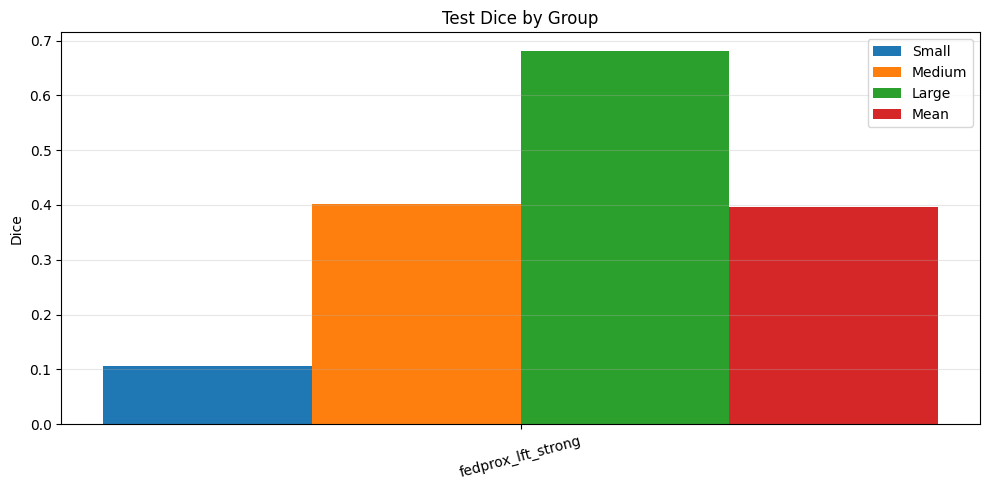

In [ ]:
rows = []
for mn, out in results.items():
    tm = out['test']; bv = out['best_val'] or {}
    rows.append({'method': mn, 'best_round': out['best_round'],
                 'best_val_fair': out['best_fair_score'],
                 'test_mean': tm['mean_dice'], 'test_small': tm['small_dice'],
                 'test_medium': tm['medium_dice'], 'test_large': tm['large_dice'],
                 'test_fair': tm['fair_score'], 'test_small_gap': tm['small_gap']})
summary_df = pd.DataFrame(rows).sort_values('test_fair', ascending=False)
display(summary_df.round(4))
summary_df.to_csv(OUTPUT_DIR/'test_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(rows)); w = 0.2
for j,(col,lbl) in enumerate([('test_small','Small'),('test_medium','Medium'),
                                ('test_large','Large'),('test_mean','Mean')]):
    ax.bar(x+j*w, [r[col] for r in rows], w, label=lbl)
ax.set_xticks(x+1.5*w); ax.set_xticklabels([r['method'] for r in rows], rotation=15)
ax.set_ylabel('Dice'); ax.set_title('Test Dice by Group')
ax.legend(); ax.grid(True,axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'test_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()


## 16. Drive cleanup

Run after training is fully complete.
Deletes `latest.pt` (crash recovery, not needed post-training) and PNG plots (regeneratable).
**Keeps:** `best.pt` + all CSVs (~150MB total).


In [ ]:
for method in EXPERIMENTS_TO_RUN:
    latest = OUTPUT_DIR/method/'checkpoints'/f'{method}_latest.pt'
    if latest.exists():
        os.remove(str(latest)); print(f'Deleted: {latest.name}')
    best = OUTPUT_DIR/method/'checkpoints'/f'{method}_best.pt'
    print(f'Kept: {best.name} ({best.stat().st_size/1e6:.0f} MB)')

for png in OUTPUT_DIR.glob('*.png'):
    os.remove(str(png)); print(f'Deleted: {png.name}')
print('Cleanup done. Drive usage ~150MB.')


Deleted: fedprox_lft_strong_latest.pt
Kept: fedprox_lft_strong_best.pt (51 MB)
Deleted: scwa_weights.png
Deleted: pred_vis_small.png
Deleted: pred_vis_medium.png
Deleted: pred_vis_large.png
Deleted: training_curves.png
Deleted: test_bar_chart.png
Cleanup done. Drive usage ~150MB.


## 18. Post-hoc analysis from checkpoints

**Standalone** — run from a fresh session. Mount Drive, run cells 1-11 (imports through
evaluation functions), then jump here. No retraining needed.

Produces: per-case dice CSV, improvement counts, side-by-side FLAIR|GT|pred visualisations.


Loading fedprox_lft_strong...
  Round 20 | fair=0.2550
  Inference on 90 cases...


mean     std  count
method             size_group                       
fedprox_lft_strong large       0.6811  0.1643     30
                   medium      0.4019  0.1518     30
                   small       0.1065  0.0605     30

Loading dataset: 100%|██████████| 1/1 [00:00<00:00,  2.80it/s]


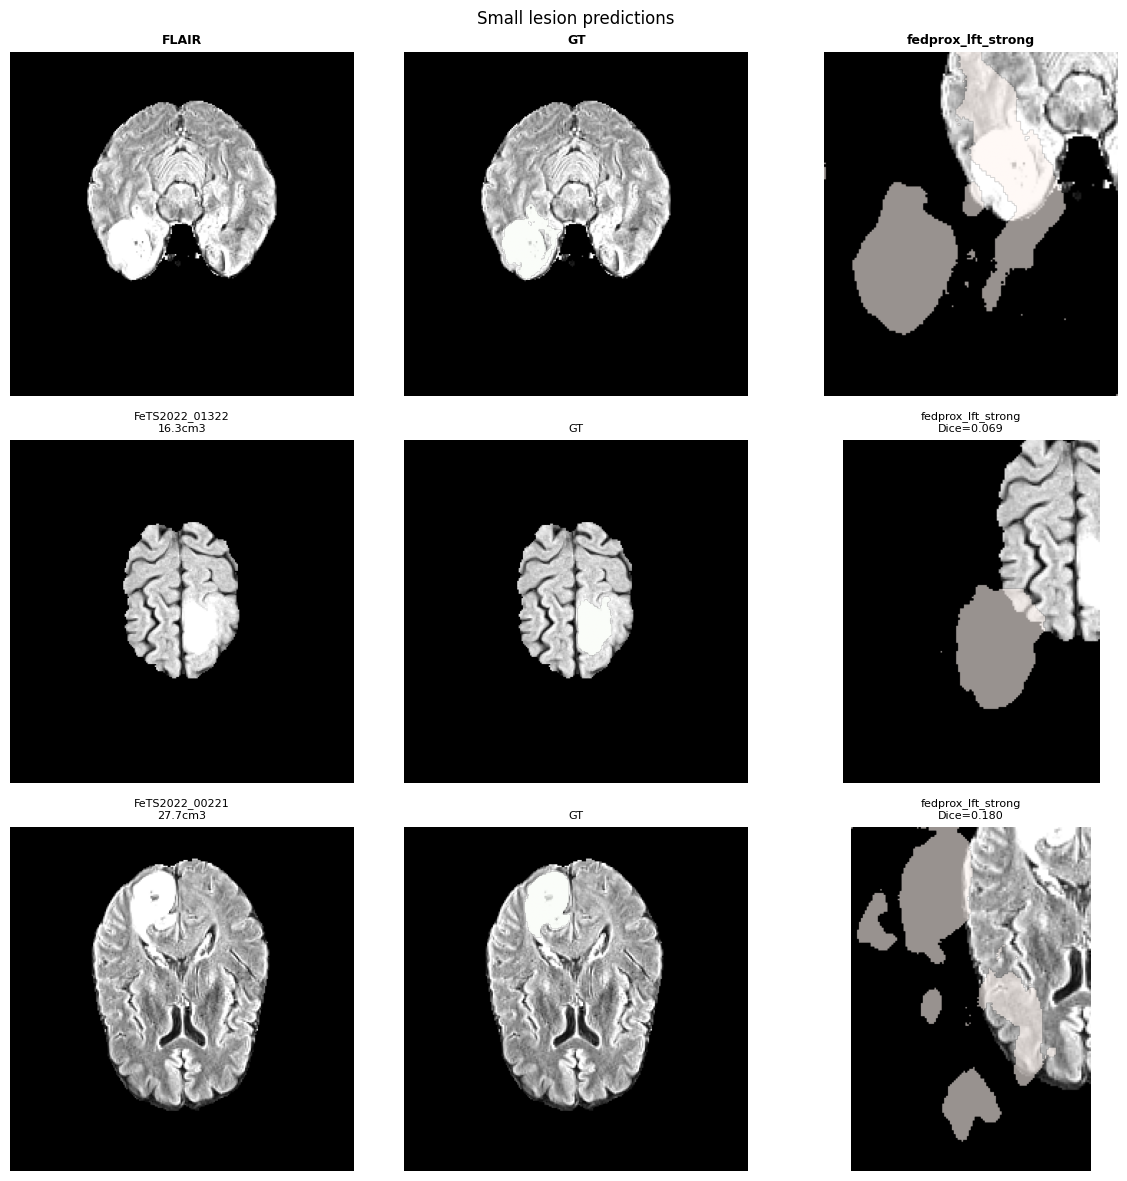

Loading dataset: 100%|██████████| 1/1 [00:00<00:00,  2.89it/s]


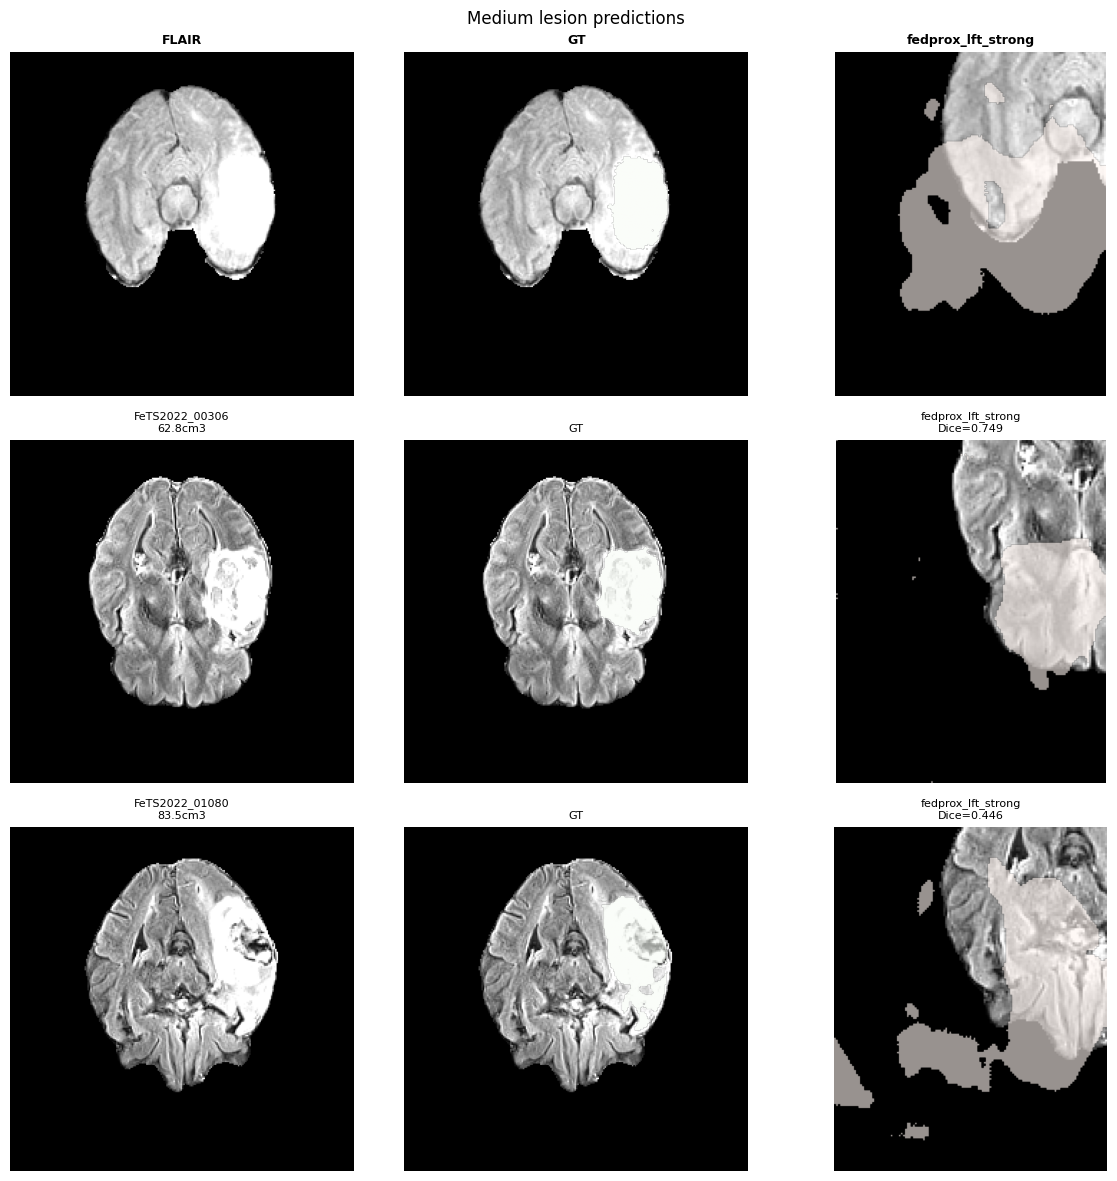

Loading dataset: 100%|██████████| 1/1 [00:00<00:00,  3.03it/s]


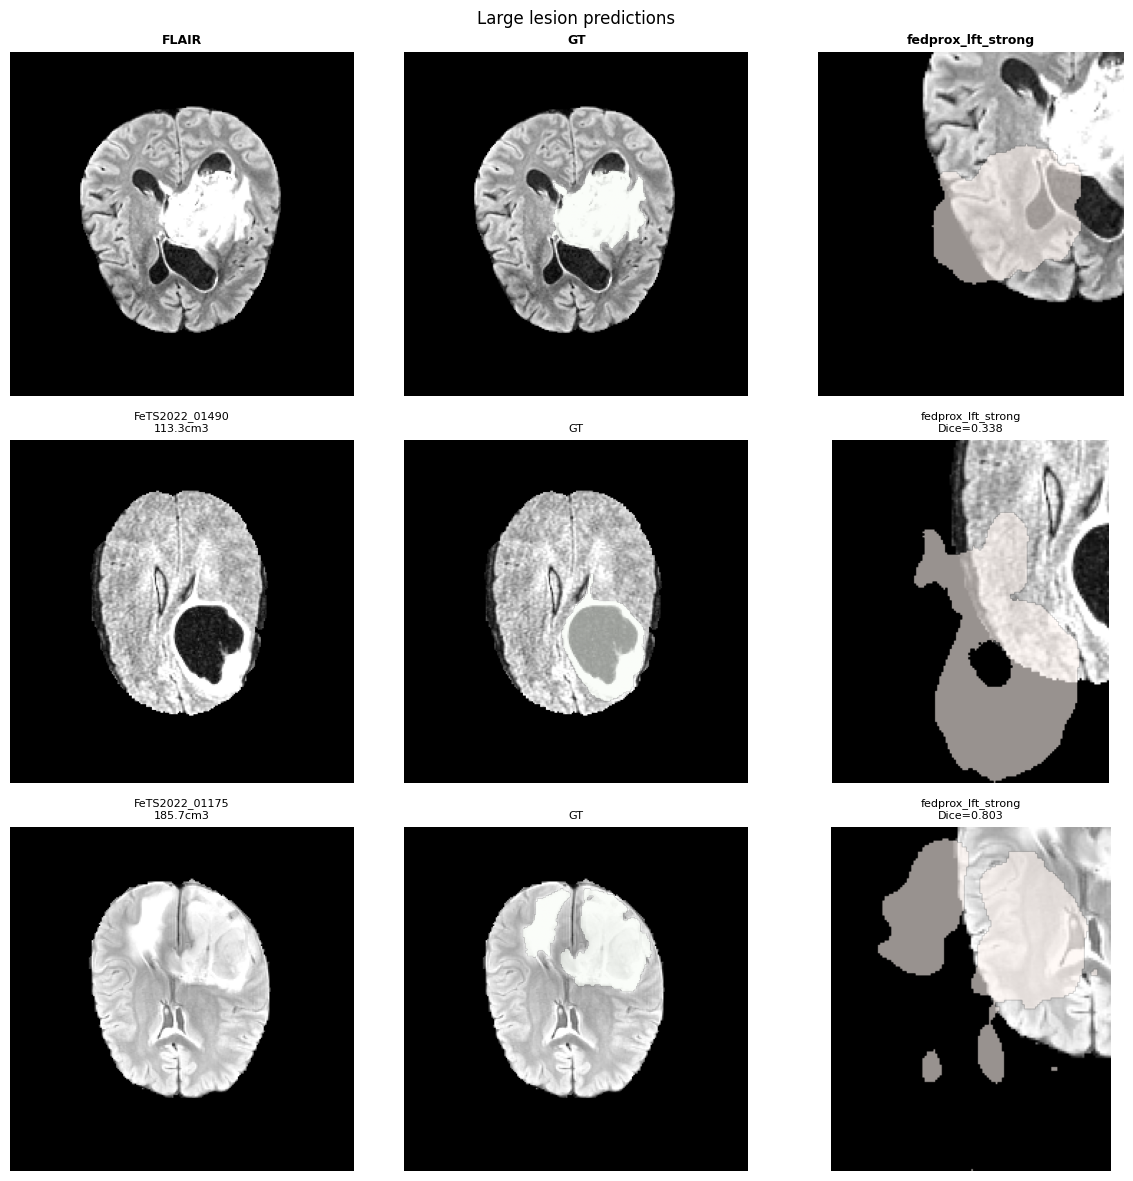

In [ ]:
import random as _rnd; _rnd.seed(42)

per_case_rows = []; method_models = {}

for method in EXPERIMENTS_TO_RUN:
    ckpt = OUTPUT_DIR/method/'checkpoints'/f'{method}_best.pt'
    if not ckpt.exists(): print(f'Not found: {ckpt}'); continue
    print(f'Loading {method}...')
    c    = torch.load(str(ckpt), map_location=device)
    m    = get_model(); m.load_state_dict(c['state_dict']); m.eval()
    method_models[method] = m
    print(f'  Round {c.get("round","?")} | fair={c.get("val_fair_score",float("nan")):.4f}')

    print(f'  Inference on {len(test_records)} cases...')
    with torch.inference_mode():
        for batch, rec in zip(test_loader, test_records):
            x = to_dev(batch['image'])
            y = (batch['label'].to(device)>0).float()
            d = hard_dice(predict_volume(m,x), y)
            per_case_rows.append({'method':method,'case_name':rec['case_name'],
                                   'size_group':rec['size_group'],
                                   'lesion_cm3':rec['lesion_cm3'],'dice':d})

per_case_df = pd.DataFrame(per_case_rows)
per_case_df.to_csv(OUTPUT_DIR/'per_case_test_dice.csv', index=False)
display(per_case_df.groupby(['method','size_group'])['dice'].agg(['mean','std','count']).round(4))

if len(EXPERIMENTS_TO_RUN) >= 2:
    m0,m1 = EXPERIMENTS_TO_RUN[0], EXPERIMENTS_TO_RUN[1]
    piv = per_case_df.pivot(index='case_name',columns='method',values='dice').dropna()
    if m0 in piv.columns and m1 in piv.columns:
        piv['improved'] = piv[m1]>piv[m0]; piv['delta'] = piv[m1]-piv[m0]
        piv = piv.join(per_case_df[['case_name','size_group']].drop_duplicates().set_index('case_name'))
        print(f'\nCases where {m1} > {m0}:')
        display(piv.groupby('size_group')['improved'].agg(
            lambda x: f'{int(x.sum())}/{len(x)} ({100*x.mean():.0f}%)'))
        piv.to_csv(OUTPUT_DIR/'per_case_delta.csv')

def show_preds(meta_list, group, n=3):
    cases = [m for m in meta_list if m['size_group']==group]
    if not cases or not method_models: return
    chosen = _rnd.sample(cases, min(n, len(cases)))
    ncols  = 2+len(method_models)
    fig,axes = plt.subplots(len(chosen),ncols,figsize=(4*ncols,4*len(chosen)))
    if len(chosen)==1: axes=np.array([axes])
    fig.suptitle(f'{group.capitalize()} lesion predictions', fontsize=12)
    for i,meta in enumerate(chosen):
        rec   = resolve_case_files(meta['case_path'])
        flair = nib.load(rec['flair']).get_fdata().astype(np.float32)
        mask  = (nib.load(rec['label']).get_fdata()>0).astype(np.uint8)
        z = int(np.argmax(mask.sum(axis=(0,1)))) if mask.sum()>0 else flair.shape[2]//2
        lo,hi = np.percentile(flair,1),np.percentile(flair,99)
        img   = np.clip((flair[:,:,z]-lo)/(hi-lo+1e-8),0,1)
        axes[i,0].imshow(img.T,cmap='gray',origin='lower')
        axes[i,0].set_title(f'{meta["case_name"]}\n{meta["lesion_cm3"]:.1f}cm3',fontsize=8)
        axes[i,0].axis('off')
        axes[i,1].imshow(img.T,cmap='gray',origin='lower')
        axes[i,1].imshow(np.ma.masked_where(mask[:,:,z].T==0,mask[:,:,z].T),
                         cmap='Greens',alpha=0.6,origin='lower')
        axes[i,1].set_title('GT',fontsize=8); axes[i,1].axis('off')
        for j,(mn,mm) in enumerate(method_models.items()):
            vds = build_eval_dataset([rec], f'vis_{mn}')
            vb  = next(iter(build_loader(vds,1,False,workers=0)))
            vx  = to_dev(vb['image']); vy=(vb['label'].to(device)>0).float()
            with torch.inference_mode(): lg=predict_volume(mm,vx)
            pred=(torch.sigmoid(lg)[0,0].cpu().numpy()>0.5).astype(np.uint8)
            d=hard_dice(lg,vy)
            axes[i,2+j].imshow(img.T,cmap='gray',origin='lower')
            axes[i,2+j].imshow(np.ma.masked_where(pred[:,:,z].T==0,pred[:,:,z].T),
                               cmap='Reds',alpha=0.6,origin='lower')
            axes[i,2+j].set_title(f'{mn}\nDice={d:.3f}',fontsize=8)
            axes[i,2+j].axis('off')
    hdrs=['FLAIR','GT']+list(method_models.keys())
    for ax,h in zip(axes[0],hdrs): ax.set_title(h,fontweight='bold',fontsize=9)
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR/f'pred_vis_{group}.png'),dpi=130,bbox_inches='tight')
    plt.show()

for grp in ['small','medium','large']:
    show_preds(test_meta, grp, n=3)


## 19. Write-up notes

### Key comparisons
- Experiment B2 result vs Baseline A = FedProx + Strong FTL effect (no SCWA)
- Experiment C vs Experiment B2 = **pure SCWA-LW contribution** (cleanest isolation)
- Primary metric: **test_small_dice** (research question)
- Secondary: **test_fair_score** (harmonic mean — balances all groups)
- Tertiary: **test_mean_dice**

### Story arc (Experiment B2)
Baseline A used standard FedAvg + weak FocalTversky.
Experiment B2 upgrades to strong FocalTversky (LAMBDA=2.0, beta=0.85) and adds
FedProx (μ=0.01) to penalise client drift — but keeps aggregation as plain FedAvg.
Result: small-tumour Dice **drops** vs Baseline A (0.107 vs 0.116).
Why: FedProx penalises Client 1 for diverging from the global model, but Client 1
holds the most small-tumour cases — its divergence is beneficial. Suppressing it
without fixing the aggregation bias removes the signal we actually need.

### Why B2 matters
B2 is the critical ablation control. Comparing Experiment C to B2 isolates SCWA-LW's
contribution exactly — both share identical loss and regularisation, and the only
difference is whether SCWA-LW weights are applied at decoder aggregation.
C vs B2: +0.021 small-Dice, +0.036 fair score → SCWA-LW is the dominant driver.

### Limitations
- Static FedAvg weights do not adapt to changing client distributions
- Optimal FedProx μ may vary across datasets
- Single random seed — cannot report variance across splits
